In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp

choices = pd.read_csv("maxdiff_design_and_choices.csv")
labels = pd.read_csv("maxdiff_item_labels.csv")

choices.head(), labels.head()


(                  Record ID  Task  Position  Item  Response
 0  69fb85fbd66b452e6decf4f7     1         1     5         0
 1  69fb85fbd66b452e6decf4f7     1         2     7         1
 2  69fb85fbd66b452e6decf4f7     1         3     4         0
 3  69fb85fbd66b452e6decf4f7     1         4     1        -1
 4  69fb85fbd66b452e6decf4f7     2         1     8        -1,
    Item #                                               Item  Unnamed: 2  \
 0       1  MGTA 403 AI Math, Prog., & Analytics (Summer w...         NaN   
 1       2                    MGTA 464 SQL (Summer with Nijs)         NaN   
 2       3  MGTA 451 Marketing/Finance/Operations (Summer ...         NaN   
 3       4             MGTA 452 Large Data (Fall with Hansen)         NaN   
 4       5     MGTA 453 Business Analytics (Fall with August)         NaN   
 
    Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  
 0         NaN         NaN         NaN         NaN  
 1         NaN         NaN         NaN         NaN  
 2        

In [2]:
print(choices.shape)
print(choices.columns)
print(labels.shape)
print(labels.columns)

choices.head(12)


(3910, 5)
Index(['Record ID', 'Task', 'Position', 'Item', 'Response'], dtype='object')
(10, 7)
Index(['Item #', 'Item', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')


,Record ID,Task,Position,Item,Response
0,69fb85fbd66b452e6decf4f7,1,1,5,0
1,69fb85fbd66b452e6decf4f7,1,2,7,1
2,69fb85fbd66b452e6decf4f7,1,3,4,0
3,69fb85fbd66b452e6decf4f7,1,4,1,-1
4,69fb85fbd66b452e6decf4f7,2,1,8,-1
5,69fb85fbd66b452e6decf4f7,2,2,3,0
6,69fb85fbd66b452e6decf4f7,2,3,10,1
7,69fb85fbd66b452e6decf4f7,2,4,9,0
8,69fb85fbd66b452e6decf4f7,3,1,3,0
9,69fb85fbd66b452e6decf4f7,3,2,5,0


In [3]:
# respondents, tasks, positions, items
n_respondents = choices["Record ID"].nunique()
tasks_per_respondent = choices.groupby("Record ID")["Task"].nunique().unique()
items_per_task = choices.groupby(["Record ID", "Task"])["Position"].nunique().unique()
n_items = labels["Item #"].nunique()

print("Respondents:", n_respondents)
print("Tasks per respondent:", tasks_per_respondent)
print("Items per task:", items_per_task)
print("Total items:", n_items)


Respondents: 85
Tasks per respondent: [15]
Items per task: [4 2]
Total items: 10


In [4]:
check = (
    choices.groupby(["Record ID", "Task"])["Response"]
    .agg(
        n_best=lambda x: (x == 1).sum(),
        n_worst=lambda x: (x == -1).sum(),
        n_neutral=lambda x: (x == 0).sum(),
        n_rows="count",
    )
    .reset_index()
)

check.head()


,Record ID,Task,n_best,n_worst,n_neutral,n_rows
0,69fb85fbd66b452e6decf4f7,1,1,1,2,4
1,69fb85fbd66b452e6decf4f7,2,1,1,2,4
2,69fb85fbd66b452e6decf4f7,3,1,1,2,4
3,69fb85fbd66b452e6decf4f7,4,1,1,2,4
4,69fb85fbd66b452e6decf4f7,5,1,1,2,4


In [5]:
bad_tasks = check[
    (check["n_best"] != 1)
    | (check["n_worst"] != 1)
    | (check["n_neutral"] != 2)
    | (check["n_rows"] != 4)
]

bad_tasks


,Record ID,Task,n_best,n_worst,n_neutral,n_rows
8,69fb85fbd66b452e6decf4f7,9,1,0,1,2
9,69fb85fbd66b452e6decf4f7,10,1,0,1,2
10,69fb85fbd66b452e6decf4f7,11,1,0,1,2
11,69fb85fbd66b452e6decf4f7,12,1,0,1,2
12,69fb85fbd66b452e6decf4f7,13,1,0,1,2
...,...,...,...,...,...,...
1270,6a081079b9497dcfa9637de9,11,1,0,1,2
1271,6a081079b9497dcfa9637de9,12,1,0,1,2
1272,6a081079b9497dcfa9637de9,13,1,0,1,2
1273,6a081079b9497dcfa9637de9,14,1,0,1,2


In [6]:
shown_counts = (
    choices.groupby("Item")
    .size()
    .reset_index(name="times_shown")
    .merge(labels, left_on="Item", right_on="Item #", how="left")
)

shown_counts


,Item_x,times_shown,Item #,Item_y,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1,332,1.0,"MGTA 403 AI Math, Prog., & Analytics (Summer w...",NaN,NaN,NaN,NaN,NaN
1,2,340,2.0,MGTA 464 SQL (Summer with Nijs),NaN,NaN,NaN,NaN,NaN
2,3,326,3.0,MGTA 451 Marketing/Finance/Operations (Summer ...,NaN,NaN,NaN,NaN,NaN
3,4,338,4.0,MGTA 452 Large Data (Fall with Hansen),NaN,NaN,NaN,NaN,NaN
4,5,327,5.0,MGTA 453 Business Analytics (Fall with August),NaN,NaN,NaN,NaN,NaN
5,6,323,6.0,MGTA 444 Analytics Consulting (Winter with Pet...,NaN,NaN,NaN,NaN,NaN
6,7,335,7.0,MGTA 455 Customer Analytics (Winter with Nijs),NaN,NaN,NaN,NaN,NaN
7,8,330,8.0,MGTA 454 Capstone Project (Spring with Advisor),NaN,NaN,NaN,NaN,NaN
8,9,330,9.0,MGTA 495 Marketing Analytics (Spring with Yavo...,NaN,NaN,NaN,NaN,NaN
9,10,334,10.0,MGTA 457 Biz. Intelligence Systems (Fall with ...,NaN,NaN,NaN,NaN,NaN


In [7]:
counts = (
    choices.groupby("Item")
    .agg(
        times_shown=("Response", "size"),
        times_best=("Response", lambda x: (x == 1).sum()),
        times_worst=("Response", lambda x: (x == -1).sum()),
    )
    .reset_index()
)

counts["pct_best"] = counts["times_best"] / counts["times_shown"]
counts["pct_worst"] = counts["times_worst"] / counts["times_shown"]
counts["score"] = counts["pct_best"] - counts["pct_worst"]

counts = counts.merge(labels, left_on="Item", right_on="Item #", how="left")
counts = counts.sort_values("score", ascending=False)

counts


,Item_x,times_shown,times_best,times_worst,pct_best,pct_worst,score,Item #,Item_y,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
8,9,330,199,12,0.603030,0.036364,0.566667,9.0,MGTA 495 Marketing Analytics (Spring with Yavo...,NaN,NaN,NaN,NaN,NaN
4,5,327,143,55,0.437309,0.168196,0.269113,5.0,MGTA 453 Business Analytics (Fall with August),NaN,NaN,NaN,NaN,NaN
6,7,335,155,71,0.462687,0.211940,0.250746,7.0,MGTA 455 Customer Analytics (Winter with Nijs),NaN,NaN,NaN,NaN,NaN
10,11,595,135,0,0.226891,0.000000,0.226891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,338,122,60,0.360947,0.177515,0.183432,4.0,MGTA 452 Large Data (Fall with Hansen),NaN,NaN,NaN,NaN,NaN
7,8,330,124,69,0.375758,0.209091,0.166667,8.0,MGTA 454 Capstone Project (Spring with Advisor),NaN,NaN,NaN,NaN,NaN
1,2,340,111,56,0.326471,0.164706,0.161765,2.0,MGTA 464 SQL (Summer with Nijs),NaN,NaN,NaN,NaN,NaN
9,10,334,74,55,0.221557,0.164671,0.056886,10.0,MGTA 457 Biz. Intelligence Systems (Fall with ...,NaN,NaN,NaN,NaN,NaN
0,1,332,76,90,0.228916,0.271084,-0.042169,1.0,"MGTA 403 AI Math, Prog., & Analytics (Summer w...",NaN,NaN,NaN,NaN,NaN
2,3,326,75,101,0.230061,0.309816,-0.079755,3.0,MGTA 451 Marketing/Finance/Operations (Summer ...,NaN,NaN,NaN,NaN,NaN


In [8]:
plt.figure(figsize=(8, 5))
plt.barh(counts["Item"], counts["score"])
plt.gca().invert_yaxis()
plt.xlabel("% Best - % Worst")
plt.ylabel("Class")
plt.title("MaxDiff Counts Score by Class")
plt.show()


KeyError: 'Item'

<Figure size 800x500 with 0 Axes>

In [9]:
# Clean labels
labels_clean = labels[["Item #", "Item"]].copy()
labels_clean.columns = ["item_id", "item_label"]

# Keep only real class items 1-10
choices10 = choices[choices["Item"].isin(labels_clean["item_id"])].copy()

# Sanity check by task
task_check = (
    choices10.groupby(["Record ID", "Task"])["Response"]
    .agg(
        n_best=lambda x: (x == 1).sum(),
        n_worst=lambda x: (x == -1).sum(),
        n_neutral=lambda x: (x == 0).sum(),
        n_rows="count",
    )
    .reset_index()
)

valid_tasks = task_check[
    (task_check["n_best"] == 1)
    & (task_check["n_worst"] == 1)
    & (task_check["n_neutral"] == 2)
    & (task_check["n_rows"] == 4)
][["Record ID", "Task"]]

choices_valid = choices10.merge(valid_tasks, on=["Record ID", "Task"], how="inner")

print("Original rows:", len(choices))
print("Rows after keeping items 1-10:", len(choices10))
print("Valid MaxDiff tasks:", len(valid_tasks))
print("Rows in valid tasks:", len(choices_valid))


Original rows: 3910
Rows after keeping items 1-10: 3315
Valid MaxDiff tasks: 680
Rows in valid tasks: 2720


In [10]:
counts = (
    choices_valid.groupby("Item")
    .agg(
        times_shown=("Response", "size"),
        times_best=("Response", lambda x: (x == 1).sum()),
        times_worst=("Response", lambda x: (x == -1).sum()),
    )
    .reset_index()
)

counts["pct_best"] = counts["times_best"] / counts["times_shown"]
counts["pct_worst"] = counts["times_worst"] / counts["times_shown"]
counts["score"] = counts["pct_best"] - counts["pct_worst"]

counts = (
    counts.merge(labels_clean, left_on="Item", right_on="item_id", how="left")
    .drop(columns=["item_id"])
    .sort_values("score", ascending=False)
)

counts


,Item,times_shown,times_best,times_worst,pct_best,pct_worst,score,item_label
8,9,274,147,12,0.536496,0.043796,0.492701,MGTA 495 Marketing Analytics (Spring with Yavo...
4,5,270,93,55,0.344444,0.203704,0.140741,MGTA 453 Business Analytics (Fall with August)
6,7,276,104,71,0.376812,0.257246,0.119565,MGTA 455 Customer Analytics (Winter with Nijs)
3,4,276,77,60,0.278986,0.217391,0.061594,MGTA 452 Large Data (Fall with Hansen)
7,8,272,72,69,0.264706,0.253676,0.011029,MGTA 454 Capstone Project (Spring with Advisor)
1,2,274,55,56,0.200730,0.204380,-0.003650,MGTA 464 SQL (Summer with Nijs)
9,10,266,23,55,0.086466,0.206767,-0.120301,MGTA 457 Biz. Intelligence Systems (Fall with ...
0,1,273,33,90,0.120879,0.329670,-0.208791,"MGTA 403 AI Math, Prog., & Analytics (Summer w..."
2,3,272,43,101,0.158088,0.371324,-0.213235,MGTA 451 Marketing/Finance/Operations (Summer ...
5,6,267,33,111,0.123596,0.415730,-0.292135,MGTA 444 Analytics Consulting (Winter with Pet...


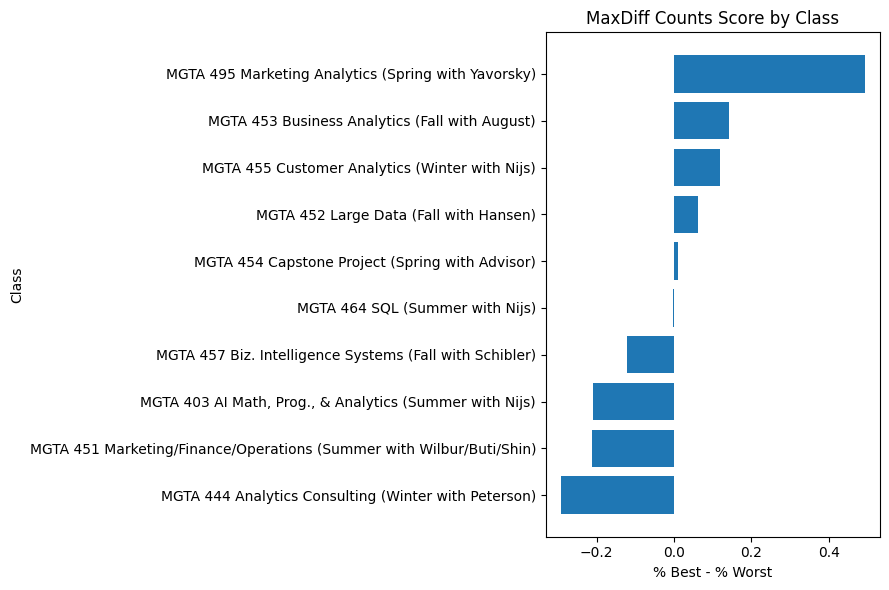

In [11]:
plt.figure(figsize=(9, 6))
plt.barh(counts["item_label"], counts["score"])
plt.gca().invert_yaxis()
plt.xlabel("% Best - % Worst")
plt.ylabel("Class")
plt.title("MaxDiff Counts Score by Class")
plt.tight_layout()
plt.show()


In [12]:
task_data = []

grouped = choices_valid.groupby(["Record ID", "Task"])

for (rid, task), g in grouped:
    shown = g["Item"].tolist()

    best = g.loc[g["Response"] == 1, "Item"].iloc[0]

    worst = g.loc[g["Response"] == -1, "Item"].iloc[0]

    task_data.append(
        {"Record ID": rid, "Task": task, "shown": shown, "best": best, "worst": worst}
    )

task_df = pd.DataFrame(task_data)

task_df.head()


,Record ID,Task,shown,best,worst
0,69fb85fbd66b452e6decf4f7,1,"[5, 7, 4, 1]",7,1
1,69fb85fbd66b452e6decf4f7,2,"[8, 3, 10, 9]",10,8
2,69fb85fbd66b452e6decf4f7,3,"[3, 5, 2, 6]",2,6
3,69fb85fbd66b452e6decf4f7,4,"[6, 4, 8, 7]",7,6
4,69fb85fbd66b452e6decf4f7,5,"[2, 9, 7, 1]",2,1


In [13]:
from scipy.special import logsumexp


def full_beta(beta_free):
    """
    beta_1 = 0 fixed
    """
    return np.concatenate([[0], beta_free])


def mnl_loglik(beta_free, task_df):

    beta = full_beta(beta_free)

    ll = 0

    for _, row in task_df.iterrows():
        shown = row["shown"]

        best = row["best"]

        worst = row["worst"]

        # convert item ids (1-10) -> python index (0-9)
        shown_idx = [j - 1 for j in shown]

        best_idx = best - 1
        worst_idx = worst - 1

        # BEST choice
        v_best = beta[shown_idx]

        ll += beta[best_idx] - logsumexp(v_best)

        # WORST choice
        remaining = [j for j in shown if j != best]

        remaining_idx = [j - 1 for j in remaining]

        v_worst = -beta[remaining_idx]

        ll += -beta[worst_idx] - logsumexp(v_worst)

    return ll


In [14]:
beta0 = np.zeros(9)

mnl_loglik(beta0, task_df)


np.float64(-1689.7365218558375)

In [15]:
from scipy.optimize import minimize

out = minimize(lambda b: -mnl_loglik(b, task_df), x0=np.zeros(9), method="BFGS")

out.success


False

In [16]:
print(out.message)
print(out.x)


Desired error not necessarily achieved due to precision loss.
[ 0.43801326 -0.06664396  0.55530209  0.74446984 -0.23882229  0.65626524
  0.44328231  1.62980543  0.23590271]


In [17]:
beta_hat_free = out.x
beta_hat = full_beta(beta_hat_free)

mle_results = pd.DataFrame({"Item": range(1, 11), "beta_hat": beta_hat}).merge(
    labels_clean, left_on="Item", right_on="item_id", how="left"
)

mle_results["share"] = (
    np.exp(mle_results["beta_hat"]) / np.exp(mle_results["beta_hat"]).sum()
)
mle_results = mle_results.sort_values("share", ascending=False)

mle_results


,Item,beta_hat,item_id,item_label,share
8,9,1.629805,9,MGTA 495 Marketing Analytics (Spring with Yavo...,0.283890
4,5,0.744470,5,MGTA 453 Business Analytics (Fall with August),0.117126
6,7,0.656265,7,MGTA 455 Customer Analytics (Winter with Nijs),0.107238
3,4,0.555302,4,MGTA 452 Large Data (Fall with Hansen),0.096939
7,8,0.443282,8,MGTA 454 Capstone Project (Spring with Advisor),0.086666
1,2,0.438013,2,MGTA 464 SQL (Summer with Nijs),0.086211
9,10,0.235903,10,MGTA 457 Biz. Intelligence Systems (Fall with ...,0.070435
0,1,0.000000,1,"MGTA 403 AI Math, Prog., & Analytics (Summer w...",0.055633
2,3,-0.066644,3,MGTA 451 Marketing/Finance/Operations (Summer ...,0.052047
5,6,-0.238822,6,MGTA 444 Analytics Consulting (Winter with Pet...,0.043814


In [18]:
hessian_inv = out.hess_inv

se_free = np.sqrt(np.diag(hessian_inv))

se = np.concatenate([[np.nan], se_free])

mle_results["se"] = se

mle_results


,Item,beta_hat,item_id,item_label,share,se
8,9,1.629805,9,MGTA 495 Marketing Analytics (Spring with Yavo...,0.283890,NaN
4,5,0.744470,5,MGTA 453 Business Analytics (Fall with August),0.117126,0.035391
6,7,0.656265,7,MGTA 455 Customer Analytics (Winter with Nijs),0.107238,0.076165
3,4,0.555302,4,MGTA 452 Large Data (Fall with Hansen),0.096939,0.078596
7,8,0.443282,8,MGTA 454 Capstone Project (Spring with Advisor),0.086666,0.065254
1,2,0.438013,2,MGTA 464 SQL (Summer with Nijs),0.086211,0.118447
9,10,0.235903,10,MGTA 457 Biz. Intelligence Systems (Fall with ...,0.070435,0.073153
0,1,0.000000,1,"MGTA 403 AI Math, Prog., & Analytics (Summer w...",0.055633,0.051570
2,3,-0.066644,3,MGTA 451 Marketing/Finance/Operations (Summer ...,0.052047,0.054894
5,6,-0.238822,6,MGTA 444 Analytics Consulting (Winter with Pet...,0.043814,0.016175


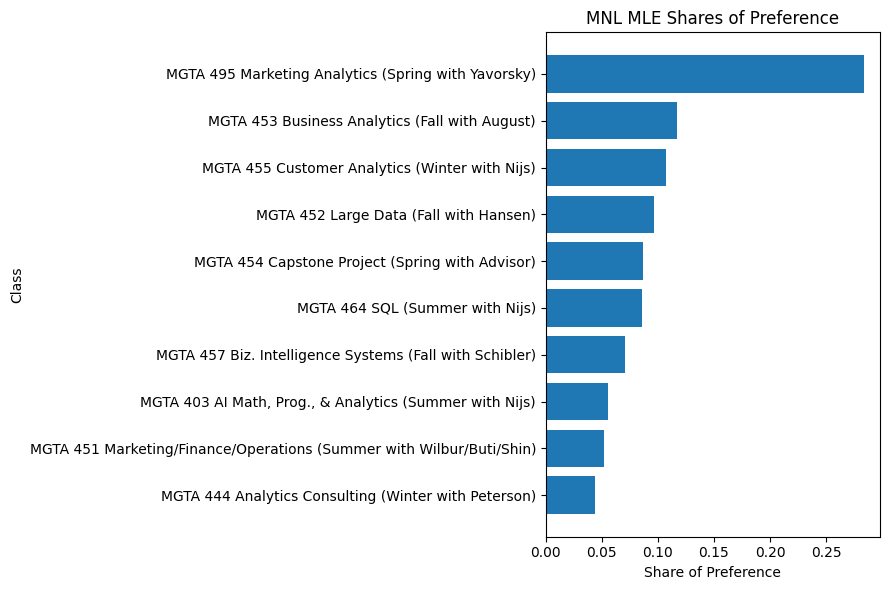

In [19]:
plt.figure(figsize=(9, 6))

plt.barh(mle_results["item_label"], mle_results["share"])

plt.gca().invert_yaxis()

plt.xlabel("Share of Preference")
plt.ylabel("Class")

plt.title("MNL MLE Shares of Preference")

plt.tight_layout()
plt.show()


In [20]:
def log_prior(beta_free):

    return np.sum(-0.5 * (beta_free**2) / 10)


def log_posterior(beta_free, task_df):

    return mnl_loglik(beta_free, task_df) + log_prior(beta_free)


In [21]:
def mh_sampler(beta0, n_iter, step, task_df):

    K = len(beta0)

    draws = np.zeros((n_iter, K))

    beta = beta0.copy()

    lp = log_posterior(beta, task_df)

    accept = 0

    for t in range(n_iter):
        beta_star = beta + np.random.normal(0, step, K)

        lp_star = log_posterior(beta_star, task_df)

        if np.log(np.random.rand()) < (lp_star - lp):
            beta = beta_star
            lp = lp_star

            accept += 1

        draws[t] = beta

    accept_rate = accept / n_iter

    return {"draws": draws, "accept_rate": accept_rate}


In [22]:
mh_out = mh_sampler(beta0=np.zeros(9), n_iter=20000, step=0.08, task_df=task_df)

mh_out["accept_rate"]


0.29095

In [23]:
mh_out["accept_rate"]


0.29095

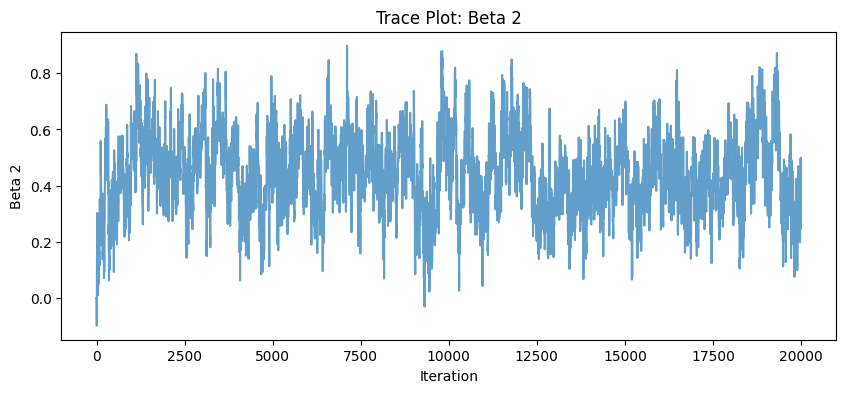

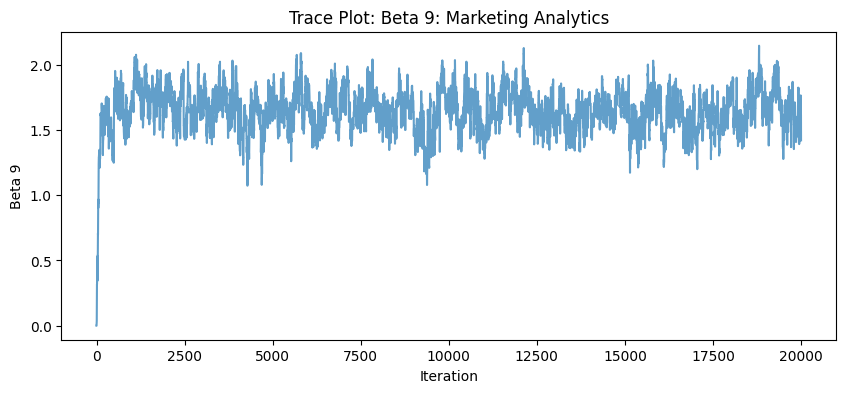

In [24]:
draws = mh_out["draws"]

plt.figure(figsize=(10, 4))
plt.plot(draws[:, 0], alpha=0.7)
plt.title("Trace Plot: Beta 2")
plt.xlabel("Iteration")
plt.ylabel("Beta 2")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(draws[:, 7], alpha=0.7)
plt.title("Trace Plot: Beta 9: Marketing Analytics")
plt.xlabel("Iteration")
plt.ylabel("Beta 9")
plt.show()


In [25]:
burn = 5000
post_draws = draws[burn:]

post_beta_free_mean = post_draws.mean(axis=0)
post_beta_free_lower = np.percentile(post_draws, 2.5, axis=0)
post_beta_free_upper = np.percentile(post_draws, 97.5, axis=0)

post_beta_mean = full_beta(post_beta_free_mean)
post_beta_lower = np.concatenate([[np.nan], post_beta_free_lower])
post_beta_upper = np.concatenate([[np.nan], post_beta_free_upper])

# shares for each draw
post_beta_full_draws = np.column_stack([np.zeros(post_draws.shape[0]), post_draws])
exp_draws = np.exp(post_beta_full_draws)
share_draws = exp_draws / exp_draws.sum(axis=1, keepdims=True)

post_share_mean = share_draws.mean(axis=0)
post_share_lower = np.percentile(share_draws, 2.5, axis=0)
post_share_upper = np.percentile(share_draws, 97.5, axis=0)

bayes_results = pd.DataFrame(
    {
        "Item": range(1, 11),
        "posterior_beta_mean": post_beta_mean,
        "beta_ci_lower": post_beta_lower,
        "beta_ci_upper": post_beta_upper,
        "posterior_share_mean": post_share_mean,
        "share_ci_lower": post_share_lower,
        "share_ci_upper": post_share_upper,
    }
).merge(labels_clean, left_on="Item", right_on="item_id", how="left")

bayes_results = bayes_results.sort_values("posterior_share_mean", ascending=False)

bayes_results


,Item,posterior_beta_mean,beta_ci_lower,beta_ci_upper,posterior_share_mean,share_ci_lower,share_ci_upper,item_id,item_label
8,9,1.643576,1.357783,1.929867,0.285201,0.242667,0.332333,9,MGTA 495 Marketing Analytics (Spring with Yavo...
4,5,0.753765,0.468824,1.024192,0.117287,0.096223,0.139913,5,MGTA 453 Business Analytics (Fall with August)
6,7,0.662457,0.394742,0.961175,0.107091,0.087681,0.129543,7,MGTA 455 Customer Analytics (Winter with Nijs)
3,4,0.562957,0.285429,0.853499,0.096926,0.079788,0.115872,4,MGTA 452 Large Data (Fall with Hansen)
7,8,0.457405,0.182027,0.733758,0.087249,0.070442,0.105245,8,MGTA 454 Capstone Project (Spring with Advisor)
1,2,0.439315,0.181015,0.719993,0.085641,0.071181,0.102770,2,MGTA 464 SQL (Summer with Nijs)
9,10,0.235738,-0.031258,0.507391,0.069915,0.056920,0.083966,10,MGTA 457 Biz. Intelligence Systems (Fall with ...
0,1,0.000000,NaN,NaN,0.055246,0.044539,0.067069,1,"MGTA 403 AI Math, Prog., & Analytics (Summer w..."
2,3,-0.063803,-0.332502,0.225809,0.051833,0.042092,0.062954,3,MGTA 451 Marketing/Finance/Operations (Summer ...
5,6,-0.236815,-0.518145,0.046036,0.043610,0.034692,0.052894,6,MGTA 444 Analytics Consulting (Winter with Pet...


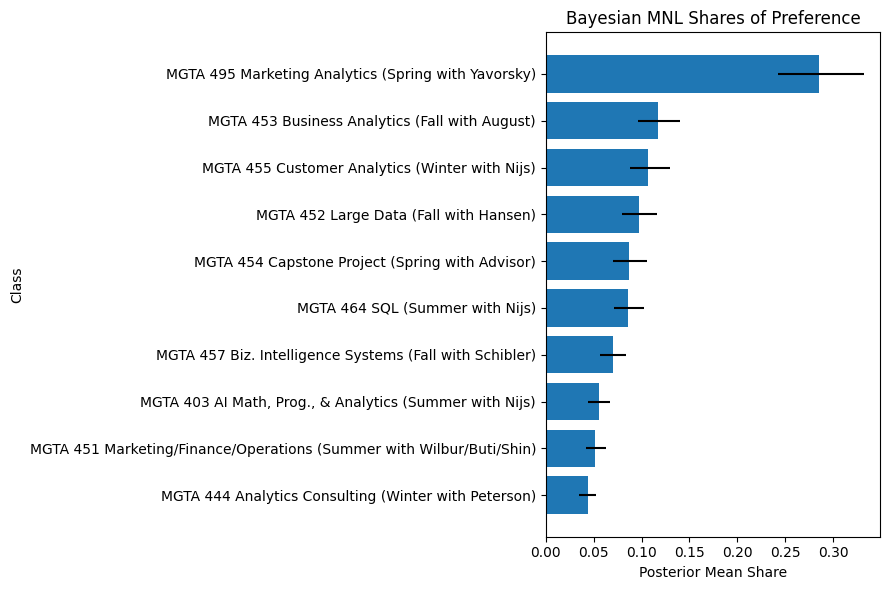

In [26]:
plt.figure(figsize=(9, 6))

plt.barh(
    bayes_results["item_label"],
    bayes_results["posterior_share_mean"],
    xerr=[
        bayes_results["posterior_share_mean"] - bayes_results["share_ci_lower"],
        bayes_results["share_ci_upper"] - bayes_results["posterior_share_mean"],
    ],
)

plt.gca().invert_yaxis()

plt.xlabel("Posterior Mean Share")
plt.ylabel("Class")

plt.title("Bayesian MNL Shares of Preference")

plt.tight_layout()
plt.show()


In [27]:
counts_rank = counts.copy()
counts_rank["counts_rank"] = counts_rank["score"].rank(ascending=False, method="min")

mle_rank = mle_results.copy()
mle_rank["mle_rank"] = mle_rank["share"].rank(ascending=False, method="min")

bayes_rank = bayes_results.copy()
bayes_rank["bayes_rank"] = bayes_rank["posterior_share_mean"].rank(
    ascending=False, method="min"
)

comparison = (
    counts_rank[["item_label", "score", "counts_rank"]]
    .merge(mle_rank[["item_label", "share", "mle_rank"]], on="item_label")
    .merge(
        bayes_rank[["item_label", "posterior_share_mean", "bayes_rank"]],
        on="item_label",
    )
)

comparison = comparison.sort_values("mle_rank")

comparison


,item_label,score,counts_rank,share,mle_rank,posterior_share_mean,bayes_rank
0,MGTA 495 Marketing Analytics (Spring with Yavo...,0.492701,1.0,0.283890,1.0,0.285201,1.0
1,MGTA 453 Business Analytics (Fall with August),0.140741,2.0,0.117126,2.0,0.117287,2.0
2,MGTA 455 Customer Analytics (Winter with Nijs),0.119565,3.0,0.107238,3.0,0.107091,3.0
3,MGTA 452 Large Data (Fall with Hansen),0.061594,4.0,0.096939,4.0,0.096926,4.0
4,MGTA 454 Capstone Project (Spring with Advisor),0.011029,5.0,0.086666,5.0,0.087249,5.0
5,MGTA 464 SQL (Summer with Nijs),-0.003650,6.0,0.086211,6.0,0.085641,6.0
6,MGTA 457 Biz. Intelligence Systems (Fall with ...,-0.120301,7.0,0.070435,7.0,0.069915,7.0
7,"MGTA 403 AI Math, Prog., & Analytics (Summer w...",-0.208791,8.0,0.055633,8.0,0.055246,8.0
8,MGTA 451 Marketing/Finance/Operations (Summer ...,-0.213235,9.0,0.052047,9.0,0.051833,9.0
9,MGTA 444 Analytics Consulting (Winter with Pet...,-0.292135,10.0,0.043814,10.0,0.043610,10.0
